<a href="https://colab.research.google.com/github/kumarianshika4321-star/ds_anshika/blob/main/Alphapulse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# ============================================================================
# ALPHAPULSE - SECTION 2: IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import norm
import warnings
import datetime
from datetime import datetime, timedelta
import io
import os

warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


# ============================================================================
# ALPHAPULSE - SECTION 3: CONFIGURATION
# ============================================================================

class Config:
    """Configuration settings for AlphaPulse"""

    # File paths
    DATA_FILE = 'dataset.csv'  # Your dataset filename

    # Column mappings (based on your dataset)
    DATE_COLUMN = 'Date'
    PRICE_COLUMN = 'Adj Close'  # Using Adjusted Close as primary price
    VOLUME_COLUMN = 'Volume'
    RETURN_COLUMN = 'Day. Ret. Volatility'  # Daily returns column

    # Technical indicator columns (for reference)
    TECHNICAL_COLUMNS = ['SMA_1', 'SMA_5', 'SMA_20', 'EMA_12', 'EMA_26',
                          'BB_MidleBB', 'Upper BB', 'Lower RSI', 'MACD',
                          'Signal_Line', 'MACD_Hi_Sigh_Low', 'Hi_Sigh_Low']

    # Risk parameters
    RISK_FREE_RATE = 0.02  # 2% annual risk-free rate
    CONFIDENCE_LEVEL = 0.95  # 95% confidence for VaR
    VOLATILITY_WINDOW = 30  # 30-day rolling volatility

    # Monte Carlo parameters
    MC_SIMULATIONS = 10000
    MC_DAYS = 252  # Trading days in a year
    INITIAL_INVESTMENT = 1000000  # $1M portfolio

    # Visualization settings
    PLOT_THEME = 'seaborn-v0_8-darkgrid'
    COLOR_PALETTE = 'viridis'
    FIGURE_SIZE = (14, 8)

print("Configuration loaded!")

Libraries imported successfully!
Configuration loaded!


In [37]:


from google.colab import files

print(" /content/dataset.csv")
uploaded = files.upload()

# Get the filename
for filename in uploaded.keys():
    print(f" Uploaded: {filename}")
    Config.DATA_FILE = filename

# Load the dataset
df = pd.read_csv(Config.DATA_FILE)
print(f"\n Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names in your dataset:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

 /content/dataset.csv


Saving dataset.csv to dataset (3).csv
 Uploaded: dataset (3).csv

 Dataset loaded: 2313 rows × 35 columns

First 5 rows:


,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Volatility,SMA_7,...,TR,ATR,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_7,Close_Lag_14,Volume_MA,Volume_Ratio
0,09-11-2016,18.357000,18.357000,18.799999,18.357000,18.770000,19,0.147302,1.495264,18.368714,...,0.469999,0.247429,18.330000,18.124001,18.341999,18.660000,17.761999,17.502001,16.642857,1.141631
1,10-11-2016,18.716000,18.716000,18.716000,18.459999,18.475000,4,1.955653,1.542196,18.416000,...,0.358999,0.269214,18.357000,18.330000,18.124001,18.382999,18.385000,17.448000,16.928571,0.236287
2,14-11-2016,16.877001,16.877001,17.459999,16.805000,17.459999,22,-9.825811,2.355992,18.161286,...,1.910999,0.397571,18.716000,18.357000,18.330000,18.341999,18.660000,17.562000,17.642857,1.246964
3,15-11-2016,17.028999,17.028999,17.049999,17.028999,17.049999,1,0.900625,2.366026,17.967857,...,0.172998,0.397500,16.877001,18.716000,18.357000,18.124001,18.382999,17.736000,16.857143,0.059322
4,16-11-2016,16.914000,16.914000,16.924999,16.914000,16.914000,1,-0.675317,2.351349,17.763857,...,0.115000,0.394928,17.028999,16.877001,18.716000,18.330000,18.341999,17.584999,16.500000,0.060606



Column names in your dataset:
  1. Date
  2. Adj Close
  3. Close
  4. High
  5. Low
  6. Open
  7. Volume
  8. Daily_Return
  9. Volatility
  10. SMA_7
  11. SMA_14
  12. SMA_30
  13. SMA_200
  14. EMA_12
  15. EMA_26
  16. BB_Middle
  17. BB_Upper
  18. BB_Lower
  19. RSI
  20. MACD
  21. Signal_Line
  22. MACD_Histogram
  23. High_Low
  24. High_Close
  25. Low_Close
  26. TR
  27. ATR
  28. Close_Lag_1
  29. Close_Lag_2
  30. Close_Lag_3
  31. Close_Lag_5
  32. Close_Lag_7
  33. Close_Lag_14
  34. Volume_MA
  35. Volume_Ratio


In [58]:
# ============================================================================
# ALPHAPULSE - SECTION 4: DATA PREPROCESSING MODULE
# ============================================================================

class DataPreprocessor:
    """Handles data cleaning and preprocessing for your specific dataset format"""

    def __init__(self, df, config):
        self.df = df.copy()
        self.config = config
        self.processed_data = None
        self.returns = None

    def clean_data(self):
        """Clean and prepare the dataset"""
        print("\n🧹 Cleaning and preprocessing data...")

        # Convert Date column to datetime
        self.df[self.config.DATE_COLUMN] = pd.to_datetime(self.df[self.config.DATE_COLUMN])

        # Sort by date
        self.df = self.df.sort_values(self.config.DATE_COLUMN)

        # Check for missing values
        missing_values = self.df.isnull().sum()
        if missing_values.sum() > 0:
            print(f"⚠️ Missing values found:")
            for col in missing_values[missing_values > 0].index:
                print(f"   • {col}: {missing_values[col]} missing values")

            # Forward fill for price columns
            self.df[self.config.PRICE_COLUMN] = self.df[self.config.PRICE_COLUMN].fillna(method='ffill')

        # Ensure numeric columns are properly typed
        numeric_cols = [self.config.PRICE_COLUMN, self.config.VOLUME_COLUMN]
        if self.config.RETURN_COLUMN in self.df.columns:
            numeric_cols.append(self.config.RETURN_COLUMN)

        for col in numeric_cols:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Drop any remaining NaN values
        self.df = self.df.dropna(subset=[self.config.PRICE_COLUMN])

        print(f"✅ Data cleaned: {len(self.df)} rows remaining")
        return self.df

    def calculate_returns(self):
        """Calculate daily returns if not present in dataset"""
        if self.config.RETURN_COLUMN in self.df.columns:
            print(f"📈 Using existing returns column: {self.config.RETURN_COLUMN}")
            self.returns = self.df[[self.config.DATE_COLUMN, self.config.RETURN_COLUMN]].copy()
            self.returns = self.returns.set_index(self.config.DATE_COLUMN)
            self.returns.columns = ['Returns']
        else:
            print("📈 Calculating returns from price data...")
            prices = self.df.set_index(self.config.DATE_COLUMN)[self.config.PRICE_COLUMN]
            self.returns = prices.pct_change().dropna().to_frame('Returns')

        return self.returns

    def extract_technical_indicators(self):
        """Extract technical indicators for analysis"""
        tech_indicators = {}

        for col in self.config.TECHNICAL_COLUMNS:
            if col in self.df.columns:
                tech_indicators[col] = self.df.set_index(self.config.DATE_COLUMN)[col]

        if tech_indicators:
            tech_df = pd.DataFrame(tech_indicators)
            print(f"✅ Extracted {len(tech_indicators)} technical indicators")
            return tech_df
        else:
            print("ℹ️ No technical indicators found in dataset")
            return None

    def get_summary_stats(self):
        """Get summary statistics"""
        stats_df = pd.DataFrame({
            'Mean Return': self.returns['Returns'].mean() * 252,
            'Volatility': self.returns['Returns'].std() * np.sqrt(252),
            'Skewness': self.returns['Returns'].skew(),
            'Kurtosis': self.returns['Returns'].kurtosis(),
            'Min Return': self.returns['Returns'].min(),
            'Max Return': self.returns['Returns'].max()
        }, index=['Value']).T

        return stats_df

print(" DataPreprocessor class loaded")

 DataPreprocessor class loaded


In [59]:
# ============================================================================
# ALPHAPULSE - SECTION 5: RISK METRICS MODULE
# ============================================================================

class RiskMetrics:
    """Calculates VaR, Monte Carlo simulations, and rolling volatility"""

    def __init__(self, returns_series, config):
        self.returns = returns_series['Returns']
        self.config = config
        self.initial_investment = config.INITIAL_INVESTMENT

    def calculate_rolling_volatility(self, window=30):
        """Calculate rolling volatility (annualized)"""
        rolling_vol = self.returns.rolling(window=window).std() * np.sqrt(252)
        return rolling_vol

    def calculate_var_historical(self, confidence_level=0.95):
        """Calculate Historical VaR"""
        var = np.percentile(self.returns, (1 - confidence_level) * 100)
        dollar_var = var * self.initial_investment
        return var, dollar_var

    def calculate_var_parametric(self, confidence_level=0.95):
        """Calculate Parametric VaR (normal distribution)"""
        mean = self.returns.mean()
        std = self.returns.std()
        var = norm.ppf(1 - confidence_level, mean, std)
        dollar_var = var * self.initial_investment
        return var, dollar_var

    def calculate_cvar(self, confidence_level=0.95):
        """Calculate Conditional VaR (Expected Shortfall)"""
        var, _ = self.calculate_var_historical(confidence_level)
        cvar = self.returns[self.returns <= var].mean()
        dollar_cvar = cvar * self.initial_investment
        return cvar, dollar_cvar

    def monte_carlo_simulation(self, n_simulations=10000, days=252):
        """Run Monte Carlo simulation"""
        print(f"\n 🎲 Running {n_simulations:,} Monte Carlo simulations...")

        # Calculate parameters from historical returns
        mean_return = self.returns.mean()
        std_return = self.returns.std()

        # Generate random returns
        random_returns = np.random.normal(mean_return, std_return, size=(days, n_simulations))

        # Calculate cumulative returns
        cumulative_returns = np.exp(np.cumsum(random_returns, axis=0))
        portfolio_values = cumulative_returns * self.initial_investment

        # Final values
        final_values = portfolio_values[-1, :]

        # Calculate statistics
        var_95 = np.percentile(final_values, 5)
        var_99 = np.percentile(final_values, 1)
        cvar_95 = final_values[final_values <= var_95].mean()

        results = {
            'final_values': final_values,
            'portfolio_paths': portfolio_values,
            'var_95': var_95,
            'var_99': var_99,
            'cvar_95': cvar_95,
            'mean_final': final_values.mean(),
            'median_final': np.median(final_values),
            'std_final': final_values.std(),
            'prob_loss': (final_values < self.initial_investment).mean() * 100,
            'prob_gain': (final_values > self.initial_investment).mean() * 100
        }

        print(f" ✅ Monte Carlo complete!")
        print(f"   VaR(95%): ${var_95:,.0f}")
        print(f"   Probability of loss: {results['prob_loss']:.1f}%")

        return results

    def calculate_max_drawdown(self):
        """Calculate maximum drawdown"""
        # Calculate cumulative wealth
        wealth_index = (1 + self.returns).cumprod()

        # Calculate running maximum
        running_max = wealth_index.expanding().max()

        # Calculate drawdown
        drawdown = (wealth_index - running_max) / running_max

        max_dd = drawdown.min()
        max_dd_date = drawdown.idxmin()

        return max_dd, max_dd_date, drawdown

    def calculate_sharpe_ratio(self):
        """Calculate Sharpe ratio"""
        excess_returns = self.returns.mean() * 252 - self.config.RISK_FREE_RATE
        volatility = self.returns.std() * np.sqrt(252)
        sharpe = excess_returns / volatility
        return sharpe

    def calculate_calmar_ratio(self):
        """Calculate Calmar ratio (return / max drawdown)"""
        annual_return = self.returns.mean() * 252
        max_dd, _, _ = self.calculate_max_drawdown()
        calmar = annual_return / abs(max_dd) if max_dd != 0 else np.nan
        return calmar

print(" RiskMetrics class loaded")

 RiskMetrics class loaded


In [60]:
# ============================================================================
# ALPHAPULSE - SECTION 6: VISUALIZATION MODULE
# ============================================================================

class Visualizer:
    """Creates all visualizations for AlphaPulse"""

    def __init__(self, config):
        self.config = config
        plt.style.use(config.PLOT_THEME)

    def plot_price_history(self, df, price_col, date_col):
        """Plot price history"""
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        # Price chart
        axes[0].plot(df[date_col], df[price_col], linewidth=2, color='blue')
        axes[0].set_title('Price History', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Price ($)')
        axes[0].grid(True, alpha=0.3)

        # Volume chart (if available)
        if self.config.VOLUME_COLUMN in df.columns:
            axes[1].bar(df[date_col], df[self.config.VOLUME_COLUMN], color='gray', alpha=0.7)
            axes[1].set_title('Trading Volume', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Volume')
            axes[1].set_xlabel('Date')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].set_visible(False)

        plt.tight_layout()
        return fig

    def plot_returns_distribution(self, returns):
        """Plot returns distribution"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Histogram
        axes[0].hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
        axes[0].axvline(x=returns.mean(), color='green', linestyle='--', linewidth=2,
                       label=f'Mean: {returns.mean():.4f}')
        axes[0].set_title('Returns Distribution', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Daily Return')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Q-Q plot for normality check
        stats.probplot(returns, dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_rolling_volatility(self, rolling_vol, returns):
        """Plot rolling volatility"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

        # Rolling volatility
        rolling_vol.plot(ax=ax1, color='red', linewidth=2)
        ax1.axhline(y=rolling_vol.mean(), color='blue', linestyle='--', alpha=0.7,
                   label=f'Mean: {rolling_vol.mean():.2%}')
        ax1.fill_between(rolling_vol.index, rolling_vol, rolling_vol.mean(),
                        alpha=0.3, where=(rolling_vol > rolling_vol.mean()),
                        color='red', label='Above average')
        ax1.fill_between(rolling_vol.index, rolling_vol, rolling_vol.mean(),
                        alpha=0.3, where=(rolling_vol < rolling_vol.mean()),
                        color='green', label='Below average')
        ax1.set_title(f'{self.config.VOLATILITY_WINDOW}-Day Rolling Volatility (Annualized)',
                     fontsize=14, fontweight='bold')
        ax1.set_ylabel('Volatility')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Returns with volatility bands
        rolling_mean = returns.rolling(self.config.VOLATILITY_WINDOW).mean()
        rolling_std = returns.rolling(self.config.VOLATILITY_WINDOW).std()

        returns.plot(ax=ax2, color='black', alpha=0.5, label='Daily Returns')
        rolling_mean.plot(ax=ax2, color='blue', linewidth=2, label=f'{self.config.VOLATILITY_WINDOW}-day MA')
        ax2.fill_between(rolling_mean.index,
                        rolling_mean - 2*rolling_std,
                        rolling_mean + 2*rolling_std,
                        alpha=0.2, color='gray', label='±2 Std Dev')
        ax2.set_title('Returns with Volatility Bands', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Return')
        ax2.set_xlabel('Date')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_monte_carlo(self, mc_results):
        """Plot Monte Carlo simulation results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Distribution of final values
        ax1 = axes[0, 0]
        ax1.hist(mc_results['final_values'], bins=100, alpha=0.7, color='blue', edgecolor='black')
        ax1.axvline(x=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', linewidth=2,
                   label=f'Initial: ${self.config.INITIAL_INVESTMENT:,.0f}')
        ax1.axvline(x=mc_results['var_95'], color='orange', linestyle='--', linewidth=2,
                   label=f'VaR(95%): ${mc_results["var_95"]:,.0f}')
        ax1.axvline(x=mc_results['mean_final'], color='green', linestyle='--', linewidth=2,
                   label=f'Mean: ${mc_results["mean_final"]:,.0f}')
        ax1.set_title('Distribution of Portfolio Values (1 Year)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Portfolio Value ($)')
        ax1.set_ylabel('Frequency')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Cumulative probability
        ax2 = axes[0, 1]
        sorted_values = np.sort(mc_results['final_values'])
        p = np.arange(len(sorted_values)) / float(len(sorted_values))
        ax2.plot(sorted_values, p, linewidth=2)
        ax2.axvline(x=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', alpha=0.7)
        ax2.axvline(x=mc_results['var_95'], color='orange', linestyle='--', alpha=0.7)
        ax2.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Portfolio Value ($)')
        ax2.set_ylabel('Cumulative Probability')
        ax2.grid(True, alpha=0.3)

        # 3. Sample of simulation paths
        ax3 = axes[1, 0]
        n_paths = min(100, mc_results['portfolio_paths'].shape[1])
        for i in range(n_paths):
            ax3.plot(mc_results['portfolio_paths'][:, i], alpha=0.1, color='blue')
        ax3.axhline(y=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', linewidth=2)
        ax3.set_title(f'Sample of {n_paths} Simulation Paths', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Trading Days')
        ax3.set_ylabel('Portfolio Value ($)')
        ax3.grid(True, alpha=0.3)

        # 4. Risk metrics summary
        ax4 = axes[1, 1]
        ax4.axis('off')
        metrics_text = f"""
        {'='*40}
        MONTE CARLO RISK SUMMARY
        {'='*40}

        Initial Investment: ${self.config.INITIAL_INVESTMENT:,.0f}

        Value at Risk (95%): ${mc_results['var_95']:,.0f}
        Value at Risk (99%): ${mc_results['var_99']:,.0f}
        Expected Shortfall (95%): ${mc_results['cvar_95']:,.0f}

        Mean Final Value: ${mc_results['mean_final']:,.0f}
        Median Final Value: ${np.median(mc_results['final_values']):,.0f}
        Std Deviation: ${mc_results['std_final']:,.0f}

        Probability of Loss: {mc_results['prob_loss']:.1f}%
        Probability of Gain: {mc_results['prob_gain']:.1f}%

        Maximum Loss: ${self.config.INITIAL_INVESTMENT - mc_results['var_99']:,.0f}
        Maximum Gain: ${mc_results['final_values'].max() - self.config.INITIAL_INVESTMENT:,.0f}
        """
        ax4.text(0.1, 0.9, metrics_text, transform=ax4.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.suptitle('Monte Carlo Simulation Analysis (10,000 Runs)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        return fig

    def plot_drawdown(self, drawdown, max_dd, max_dd_date):
        """Plot drawdown chart"""
        fig, ax = plt.subplots(figsize=(14, 6))

        drawdown.plot(ax=ax, color='red', linewidth=1)
        ax.fill_between(drawdown.index, drawdown, 0, where=(drawdown < 0),
                       color='red', alpha=0.3)
        ax.axhline(y=max_dd, color='black', linestyle='--', alpha=0.7,
                  label=f'Max Drawdown: {max_dd:.2%} ({max_dd_date.strftime("%Y-%m-%d")})')
        ax.set_title('Portfolio Drawdown Analysis', fontsize=14, fontweight='bold')
        ax.set_ylabel('Drawdown')
        ax.set_xlabel('Date')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_technical_indicators(self, df, tech_df):
        """Plot technical indicators if available"""
        if tech_df is None or tech_df.empty:
            return None

        fig, axes = plt.subplots(3, 1, figsize=(14, 12))

        # Price and moving averages
        axes[0].plot(df[self.config.DATE_COLUMN], df[self.config.PRICE_COLUMN],
                    linewidth=2, color='black', label='Price')

        if 'SMA_20' in tech_df.columns:
            axes[0].plot(tech_df.index, tech_df['SMA_20'],
                        linewidth=1.5, color='blue', label='SMA 20')
        if 'EMA_12' in tech_df.columns:
            axes[0].plot(tech_df.index, tech_df['EMA_12'],
                        linewidth=1.5, color='red', label='EMA 12')

        axes[0].set_title('Price with Moving Averages', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Price')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Bollinger Bands
        if all(col in tech_df.columns for col in ['BB_MidleBB', 'Upper BB', 'Lower RSI']):
            axes[1].plot(tech_df.index, tech_df['BB_MidleBB'],
                        linewidth=1.5, color='blue', label='Middle BB')
            axes[1].plot(tech_df.index, tech_df['Upper BB'],
                        linewidth=1, color='gray', linestyle='--', label='Upper BB')
            axes[1].plot(tech_df.index, tech_df['Lower RSI'],
                        linewidth=1, color='gray', linestyle='--', label='Lower BB')
            axes[1].fill_between(tech_df.index, tech_df['Upper BB'], tech_df['Lower RSI'],
                                alpha=0.1, color='gray')
            axes[1].set_title('Bollinger Bands', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Price')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        # MACD
        if all(col in tech_df.columns for col in ['MACD', 'Signal_Line']):
            axes[2].plot(tech_df.index, tech_df['MACD'],
                        linewidth=1.5, color='blue', label='MACD')
            axes[2].plot(tech_df.index, tech_df['Signal_Line'],
                        linewidth=1.5, color='red', label='Signal Line')

            if 'MACD_Hi_Sigh_Low' in tech_df.columns:
                axes[2].bar(tech_df.index, tech_df['MACD_Hi_Sigh_Low'],
                           alpha=0.3, color='gray', label='Histogram')

            axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            axes[2].set_title('MACD', fontsize=14, fontweight='bold')
            axes[2].set_ylabel('MACD')
            axes[2].set_xlabel('Date')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def create_interactive_price_chart(self, df, price_col, date_col):
        """Create interactive plotly price chart"""
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                           vertical_spacing=0.03,
                           row_heights=[0.7, 0.3])

        # Price line
        fig.add_trace(
            go.Scatter(x=df[date_col], y=df[price_col],
                      mode='lines',
                      name='Price',
                      line=dict(color='blue', width=2)),
            row=1, col=1
        )

        # Volume bars
        if self.config.VOLUME_COLUMN in df.columns:
            fig.add_trace(
                go.Bar(x=df[date_col], y=df[self.config.VOLUME_COLUMN],
                       name='Volume',
                       marker_color='gray',
                       opacity=0.5),
                row=2, col=1
            )

        fig.update_layout(
            title='Interactive Price Chart',
            xaxis_title='Date',
            yaxis_title='Price',
            hovermode='x unified',
            height=600,
            showlegend=True
        )

        fig.update_xaxes(title_text="Date", row=2, col=1)
        fig.update_yaxes(title_text="Price", row=1, col=1)
        fig.update_yaxes(title_text="Volume", row=2, col=1)

        return fig

print(" Visualizer class loaded")

 Visualizer class loaded


In [65]:
# ============================================================================
# ALPHAPULSE - SECTION 7: MAIN ANALYSIS ENGINE
# ============================================================================


class AlphaPulse:
    """Main orchestrator for AlphaPulse risk monitoring system"""

    def __init__(self, config):
        self.config = config
        self.preprocessor = None
        self.risk_metrics = None
        self.visualizer = Visualizer(config)

        # Data containers
        self.raw_data = None
        self.cleaned_data = None
        self.returns = None
        self.tech_indicators = None
        self.results = {}

    def load_data(self, df):
        """Load and preprocess data"""
        self.raw_data = df
        self.preprocessor = DataPreprocessor(df, self.config)

        # Clean data
        self.cleaned_data = self.preprocessor.clean_data()

        # Calculate returns
        self.returns = self.preprocessor.calculate_returns()

        # Extract technical indicators
        self.tech_indicators = self.preprocessor.extract_technical_indicators()

        return self.cleaned_data

    def run_analysis(self):
        """Execute complete risk analysis"""
        print("\n" + "="*60)
        print("🚀 ALPHAPULSE - INVESTMENT RISK MONITOR")
        print("="*60)

        if self.returns is None:
            raise ValueError("No returns data. Run load_data() first.")

        # Initialize risk metrics
        self.risk_metrics = RiskMetrics(self.returns, self.config)

        # Calculate basic metrics
        print("\n📊 CALCULATING RISK METRICS...")
        print("-"*40)

        # VaR calculations
        var_hist, var_hist_dollar = self.risk_metrics.calculate_var_historical(self.config.CONFIDENCE_LEVEL)
        var_para, var_para_dollar = self.risk_metrics.calculate_var_parametric(self.config.CONFIDENCE_LEVEL)
        cvar, cvar_dollar = self.risk_metrics.calculate_cvar(self.config.CONFIDENCE_LEVEL)

        # Rolling volatility
        rolling_vol = self.risk_metrics.calculate_rolling_volatility(self.config.VOLATILITY_WINDOW)

        # Max drawdown
        max_dd, max_dd_date, drawdown = self.risk_metrics.calculate_max_drawdown()

        # Performance ratios
        sharpe = self.risk_metrics.calculate_sharpe_ratio()
        calmar = self.risk_metrics.calculate_calmar_ratio()

        print(f"\n📈 Portfolio Statistics:")
        print(f"  • Historical VaR (95%): {var_hist:.2%} (${var_hist_dollar:,.0f})")
        print(f"  • Parametric VaR (95%): {var_para:.2%} (${var_para_dollar:,.0f})")
        print(f"  • Conditional VaR (95%): {cvar:.2%} (${cvar_dollar:,.0f})")
        print(f"  • Current Volatility: {rolling_vol.iloc[-1]:.2%}")
        print(f"  • Avg Volatility: {rolling_vol.mean():.2%}")
        print(f"  • Sharpe Ratio: {sharpe:.2f}")
        print(f"  • Calmar Ratio: {calmar:.2f}")
        print(f"  • Max Drawdown: {max_dd:.2%} ({max_dd_date.strftime('%Y-%m-%d')})")

        # Monte Carlo Simulation
        print("\n🎲 RUNNING MONTE CARLO SIMULATION...")
        print("-"*40)
        mc_results = self.risk_metrics.monte_carlo_simulation(
            n_simulations=self.config.MC_SIMULATIONS,
            days=self.config.MC_DAYS
        )

        # Store results
        self.results = {
            'returns': self.returns,
            'rolling_volatility': rolling_vol,
            'var_historical': var_hist,
            'var_historical_dollar': var_hist_dollar,
            'var_parametric': var_para,
            'var_parametric_dollar': var_para_dollar,
            'cvar': cvar,
            'cvar_dollar': cvar_dollar,
            'sharpe_ratio': sharpe,
            'calmar_ratio': calmar,
            'max_drawdown': max_dd,
            'max_drawdown_date': max_dd_date,
            'drawdown_series': drawdown,
            'mc_results': mc_results
        }

        print("\n" + "="*60)
        print("✅ ANALYSIS COMPLETE!")
        print("="*60)

        return self.results

    def generate_visualizations(self):
        """Generate all visualizations"""
        if not self.results:
            print("⚠️ No results found. Run analysis first.")
            return

        print("\n🎨 Generating visualizations...")

        # 1. Price history
        fig1 = self.visualizer.plot_price_history(
            self.cleaned_data,
            self.config.PRICE_COLUMN,
            self.config.DATE_COLUMN
        )
        plt.show()

        # 2. Returns distribution
        fig2 = self.visualizer.plot_returns_distribution(
            self.returns['Returns']
        )
        plt.show()

        # 3. Rolling volatility
        fig3 = self.visualizer.plot_rolling_volatility(
            self.results['rolling_volatility'],
            self.returns['Returns']
        )
        plt.show()

        # 4. Monte Carlo results
        fig4 = self.visualizer.plot_monte_carlo(
            self.results['mc_results']
        )
        plt.show()

        # 5. Drawdown chart
        fig5 = self.visualizer.plot_drawdown(
            self.results['drawdown_series'],
            self.results['max_drawdown'],
            self.results['max_drawdown_date']
        )
        plt.show()

        # 6. Technical indicators (if available)
        if self.tech_indicators is not None:
            fig6 = self.visualizer.plot_technical_indicators(
                self.cleaned_data,
                self.tech_indicators
            )
            if fig6:
                plt.show()

        # 7. Interactive chart
        fig7 = self.visualizer.create_interactive_price_chart(
            self.cleaned_data,
            self.config.PRICE_COLUMN,
            self.config.DATE_COLUMN
        )
        fig7.show()

        print("✅ All visualizations generated!")

    def export_results(self):
        """Export results to CSV files"""
        print("\n💾 Exporting results to CSV...")

        # Create output directory
        !mkdir -p /content/alphapulse_output

        # 1. Cleaned data
        self.cleaned_data.to_csv('/content/alphapulse_output/cleaned_data.csv', index=False)
        print("  ✅ cleaned_data.csv")

        # 2. Returns data
        self.returns.to_csv('/content/alphapulse_output/returns.csv')
        print("  ✅ returns.csv")

        # 3. Rolling volatility
        vol_df = pd.DataFrame({
            'Date': self.results['rolling_volatility'].index,
            'Rolling_Volatility': self.results['rolling_volatility'].values
        })
        vol_df.to_csv('/content/alphapulse_output/rolling_volatility.csv', index=False)
        print("  ✅ rolling_volatility.csv")

        # 4. Monte Carlo results
        mc_df = pd.DataFrame({
            'Simulation': range(len(self.results['mc_results']['final_values'])),
            'Final_Value': self.results['mc_results']['final_values']
        })
        mc_df.to_csv('/content/alphapulse_output/monte_carlo_results.csv', index=False)
        print("  ✅ monte_carlo_results.csv")

        # 5. Drawdown series
        dd_df = pd.DataFrame({
            'Date': self.results['drawdown_series'].index,
            'Drawdown': self.results['drawdown_series'].values
        })
        dd_df.to_csv('/content/alphapulse_output/drawdown.csv', index=False)
        print("  ✅ drawdown.csv")

        # 6. Portfolio summary
        summary_df = pd.DataFrame([
            {'Metric': 'Historical VaR (95%)', 'Value': f"{self.results['var_historical']:.2%}",
             'Dollar Value': f"${self.results['var_historical_dollar']:,.0f}"},
            {'Metric': 'Parametric VaR (95%)', 'Value': f"{self.results['var_parametric']:.2%}",
             'Dollar Value': f"${self.results['var_parametric_dollar']:,.0f}"},
            {'Metric': 'Conditional VaR (95%)', 'Value': f"{self.results['cvar']:.2%}",
             'Dollar Value': f"${self.results['cvar_dollar']:,.0f}"},
            {'Metric': 'Current Volatility', 'Value': f"{self.results['rolling_volatility'].iloc[-1]:.2%}",
             'Dollar Value': '-'},
            {'Metric': 'Average Volatility', 'Value': f"{self.results['rolling_volatility'].mean():.2%}",
             'Dollar Value': '-'},
            {'Metric': 'Sharpe Ratio', 'Value': f"{self.results['sharpe_ratio']:.2f}",
             'Dollar Value': '-'},
            {'Metric': 'Calmar Ratio', 'Value': f"{self.results['calmar_ratio']:.2f}",
             'Dollar Value': '-'},
            {'Metric': 'Max Drawdown', 'Value': f"{self.results['max_drawdown']:.2%}",
             'Dollar Value': '-'},
            {'Metric': 'Max Drawdown Date', 'Value': self.results['max_drawdown_date'].strftime('%Y-%m-%d'),
             'Dollar Value': '-'}
        ])
        summary_df.to_csv('/content/alphapulse_output/portfolio_summary.csv', index=False)
        print("  ✅ portfolio_summary.csv")

        # 7. Technical indicators (if available)
        if self.tech_indicators is not None:
            self.tech_indicators.to_csv('/content/alphapulse_output/technical_indicators.csv')
            print("  ✅ technical_indicators.csv")

        print(f"\n📁 All files saved to: /content/alphapulse_output/")

        # Zip the files
        !zip -r /content/alphapulse_results.zip /content/alphapulse_output/
        print("\n📦 Created: alphapulse_results.zip")

print("✅ AlphaPulse main class loaded")

✅ AlphaPulse main class loaded


In [67]:
# ============================================================================
# ALPHAPULSE - SECTION 8: EXECUTE COMPLETE ANALYSIS
# ============================================================================

# Initialize AlphaPulse
print("🚀 Initializing AlphaPulse...")
alp = AlphaPulse(Config)

# Preprocess the 'Date' column in df to ensure correct format before passing to AlphaPulse
# The error indicates that the date format is DD-MM-YYYY, not MM-DD-YYYY
df[Config.DATE_COLUMN] = pd.to_datetime(df[Config.DATE_COLUMN], format="%d-%m-%Y")

# Load your dataset
print("\n📂 Loading dataset...")
alp.load_data(df)

# Run full analysis
results = alp.run_analysis()

print("\n" + "="*60)
print("✅ SECTION 8 COMPLETE: Analysis executed")
print("="*60)

🚀 Initializing AlphaPulse...

📂 Loading dataset...

🧹 Cleaning and preprocessing data...
✅ Data cleaned: 2313 rows remaining
📈 Calculating returns from price data...
✅ Extracted 4 technical indicators

🚀 ALPHAPULSE - INVESTMENT RISK MONITOR

📊 CALCULATING RISK METRICS...
----------------------------------------

📈 Portfolio Statistics:
  • Historical VaR (95%): -2.78% ($-27,812)
  • Parametric VaR (95%): -3.10% ($-30,998)
  • Conditional VaR (95%): -4.55% ($-45,541)
  • Current Volatility: 78.94%
  • Avg Volatility: 27.67%
  • Sharpe Ratio: 0.69
  • Calmar Ratio: 0.58
  • Max Drawdown: -40.30% (2022-09-01)

🎲 RUNNING MONTE CARLO SIMULATION...
----------------------------------------

 🎲 Running 10,000 Monte Carlo simulations...
 ✅ Monte Carlo complete!
   VaR(95%): $759,970
   Probability of loss: 22.3%

✅ ANALYSIS COMPLETE!

✅ SECTION 8 COMPLETE: Analysis executed



🎨 Generating visualizations...


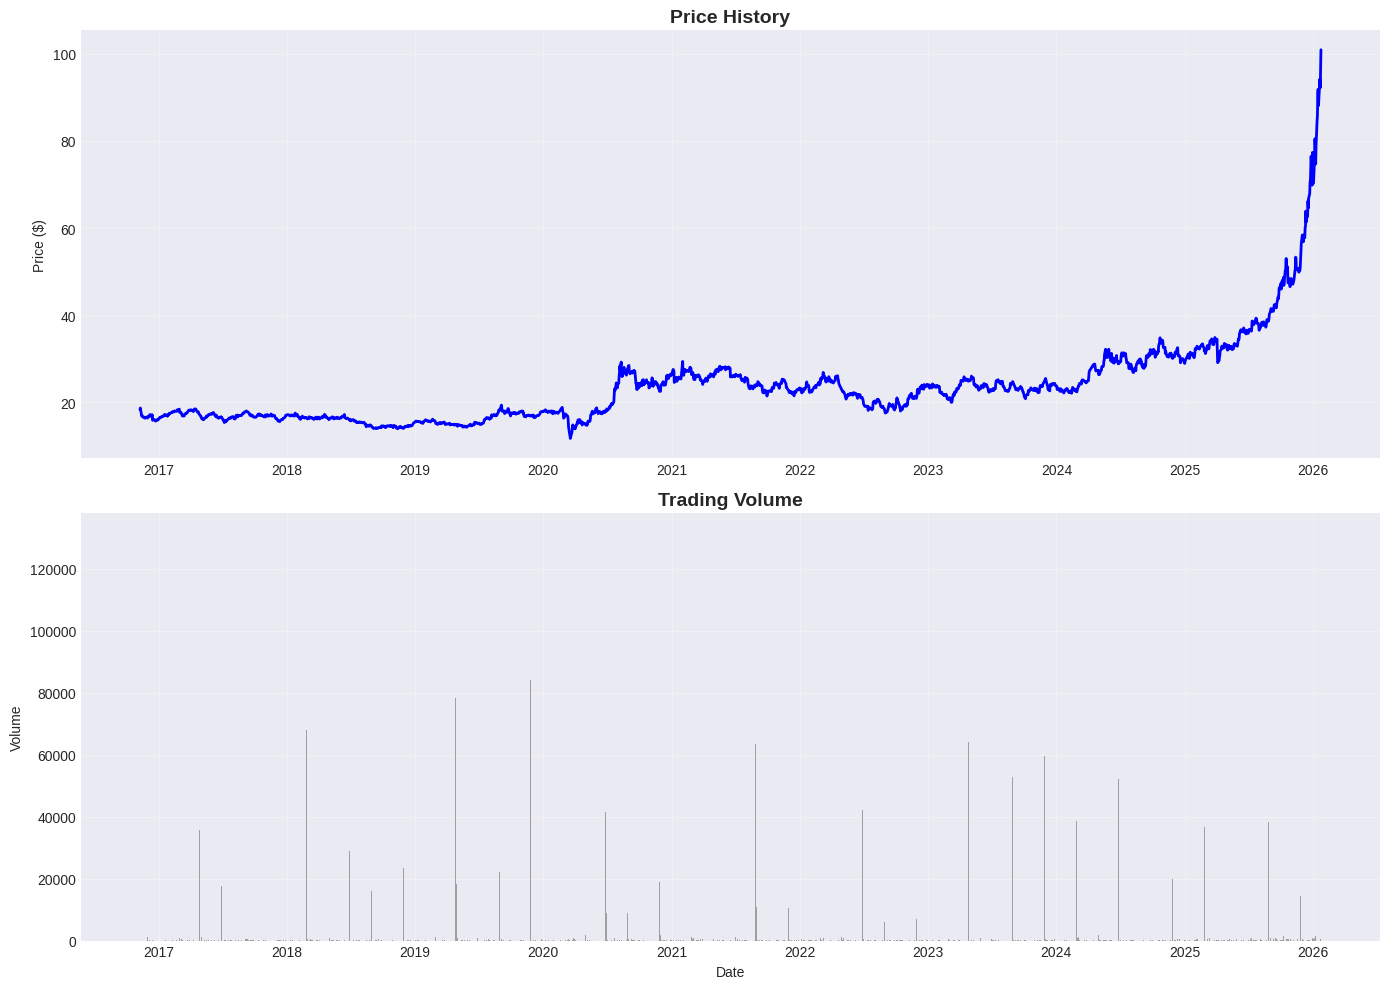

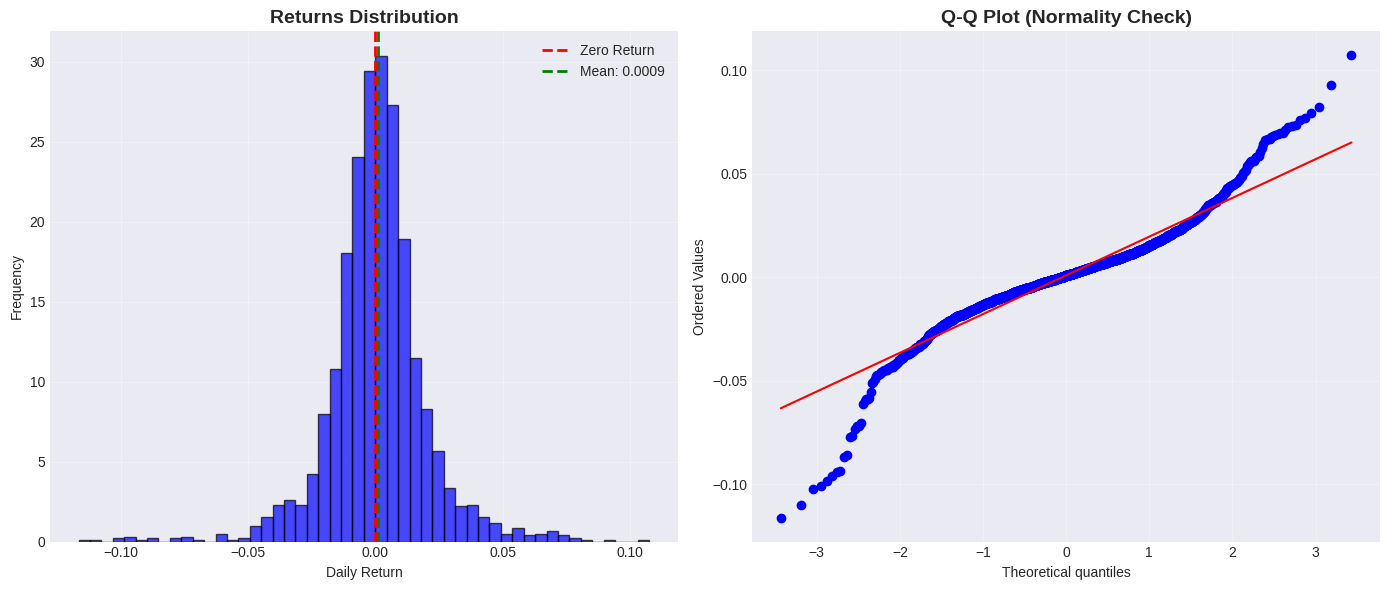

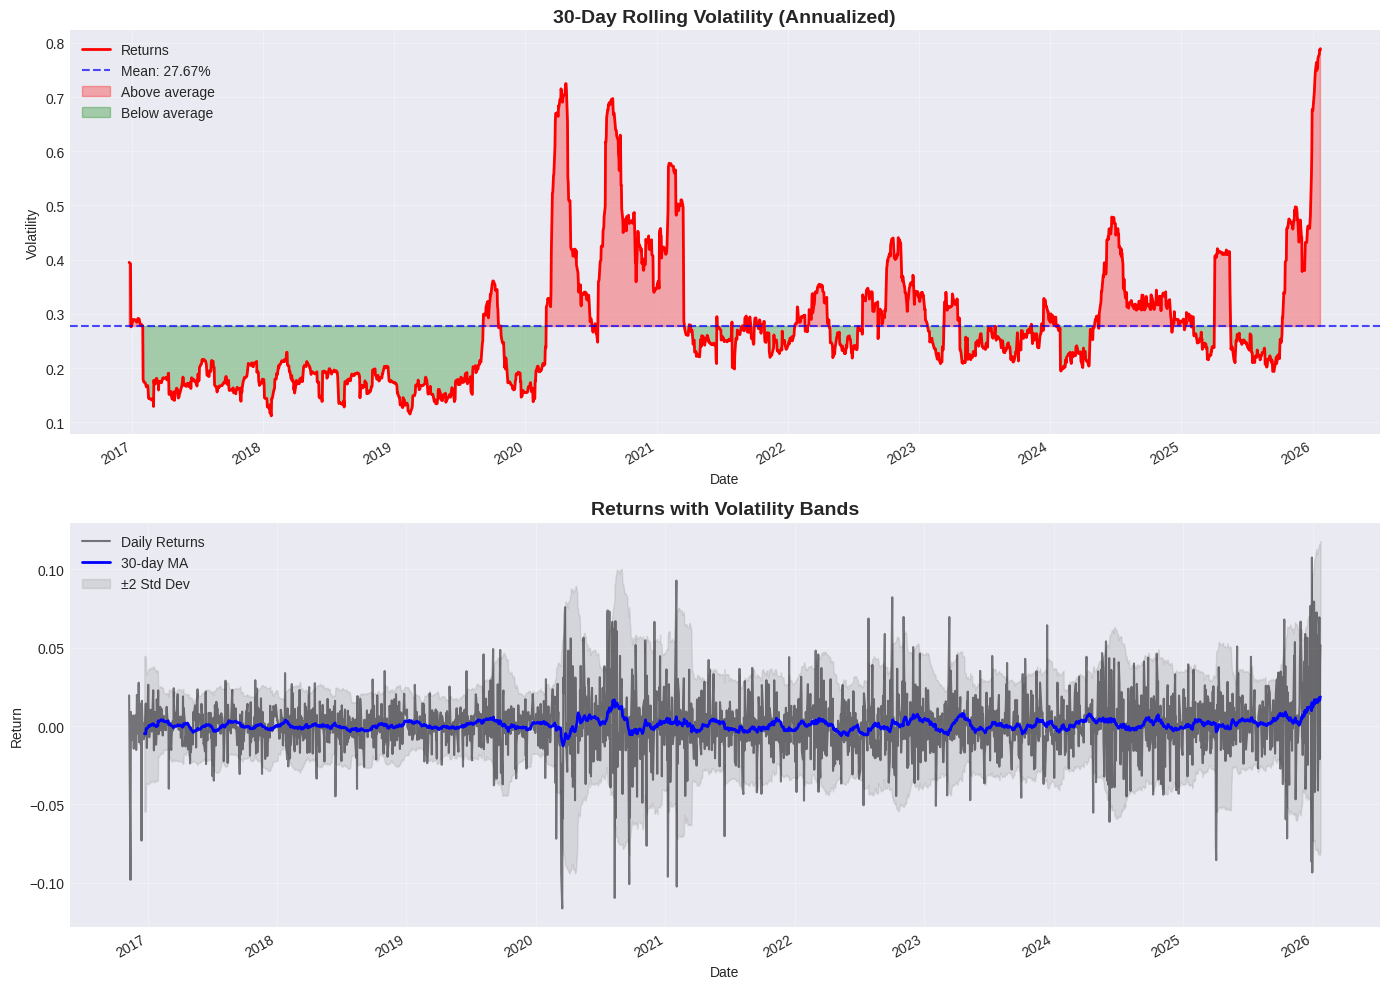

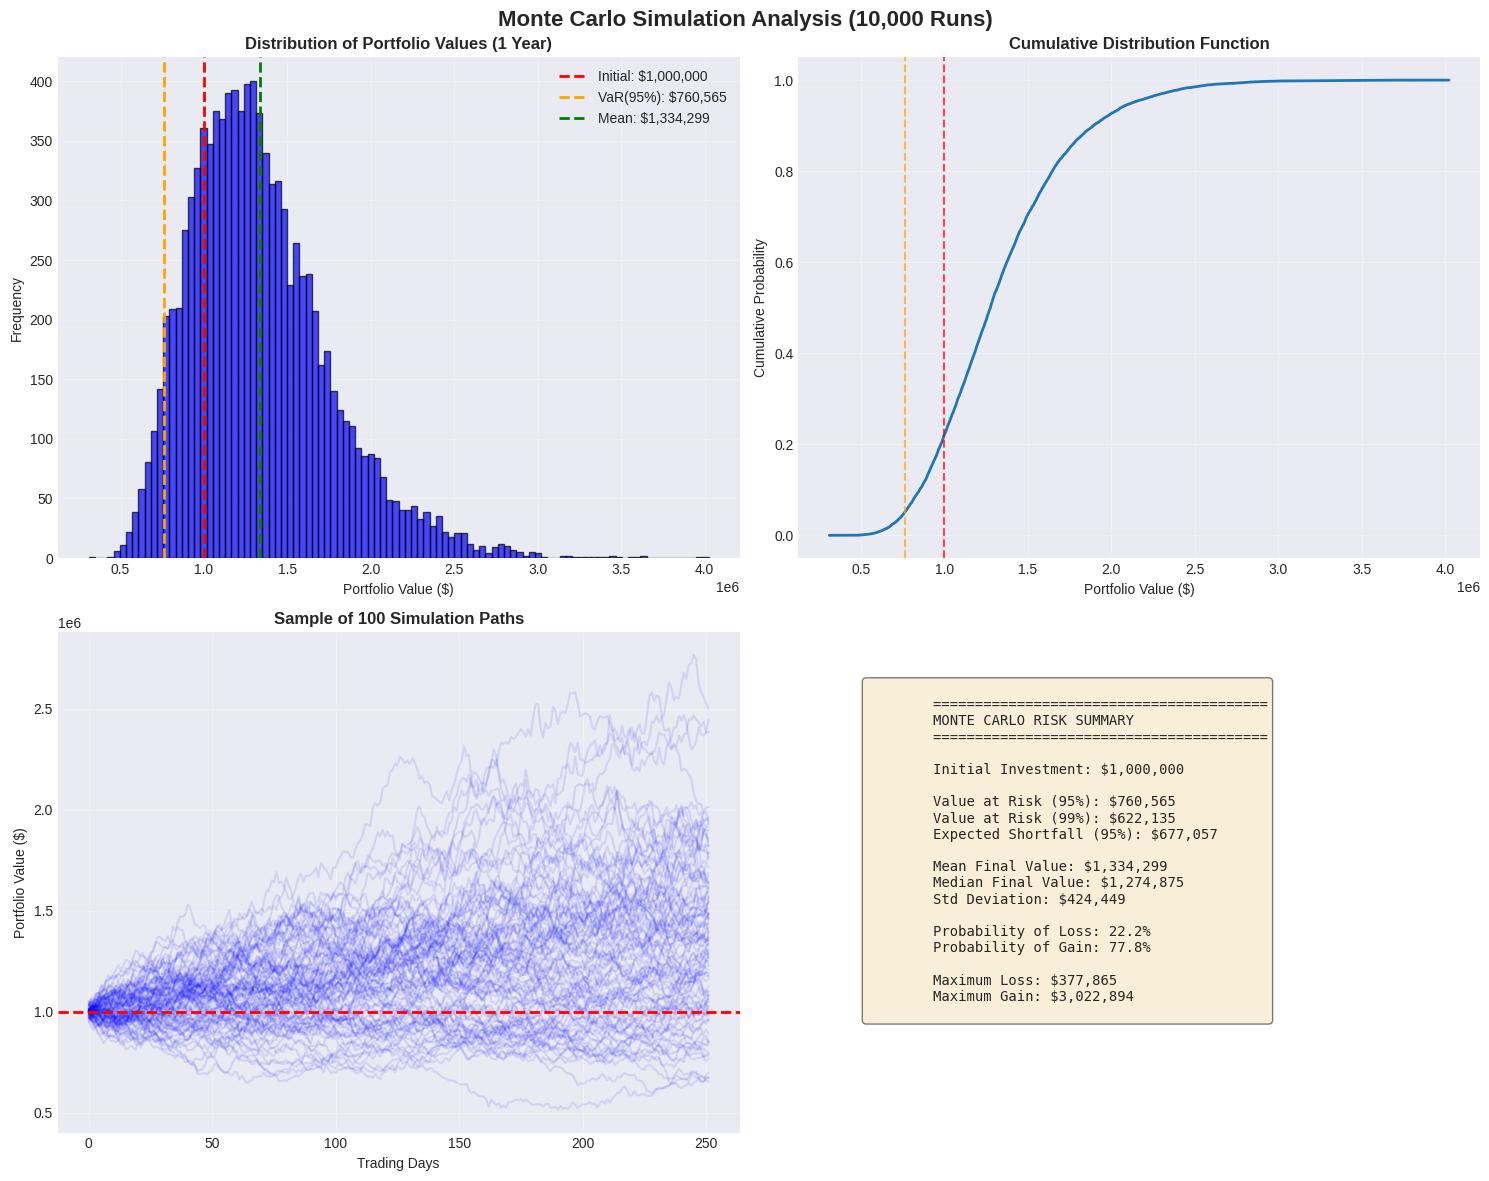

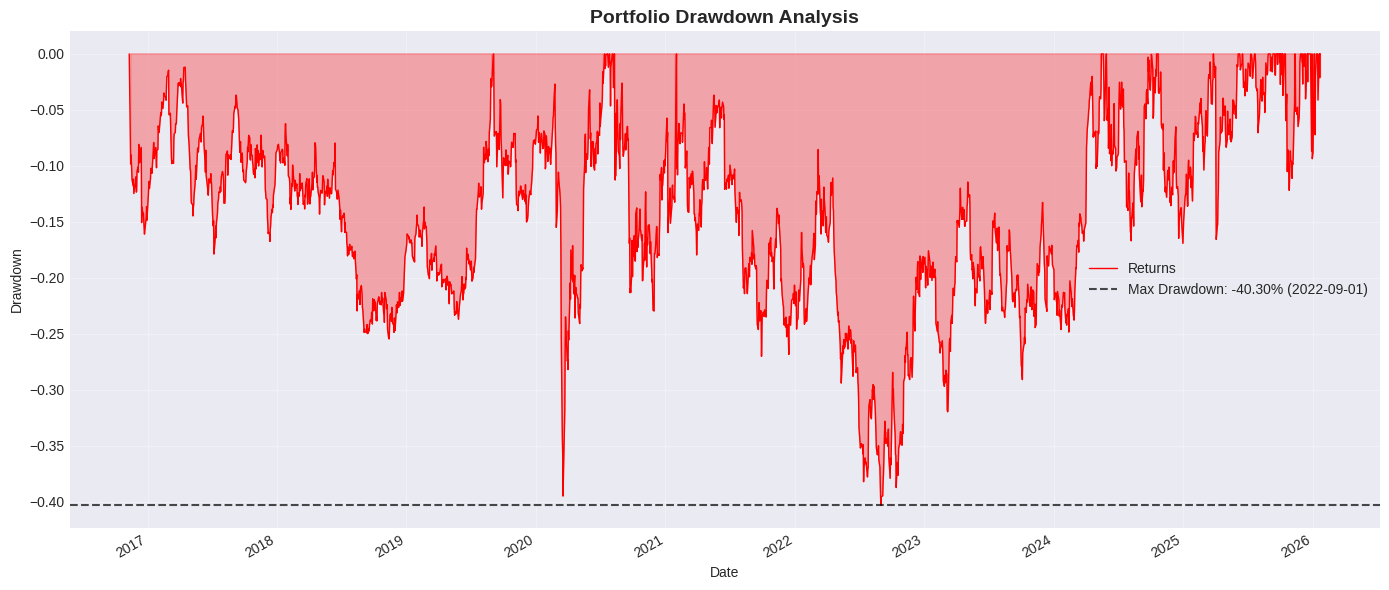

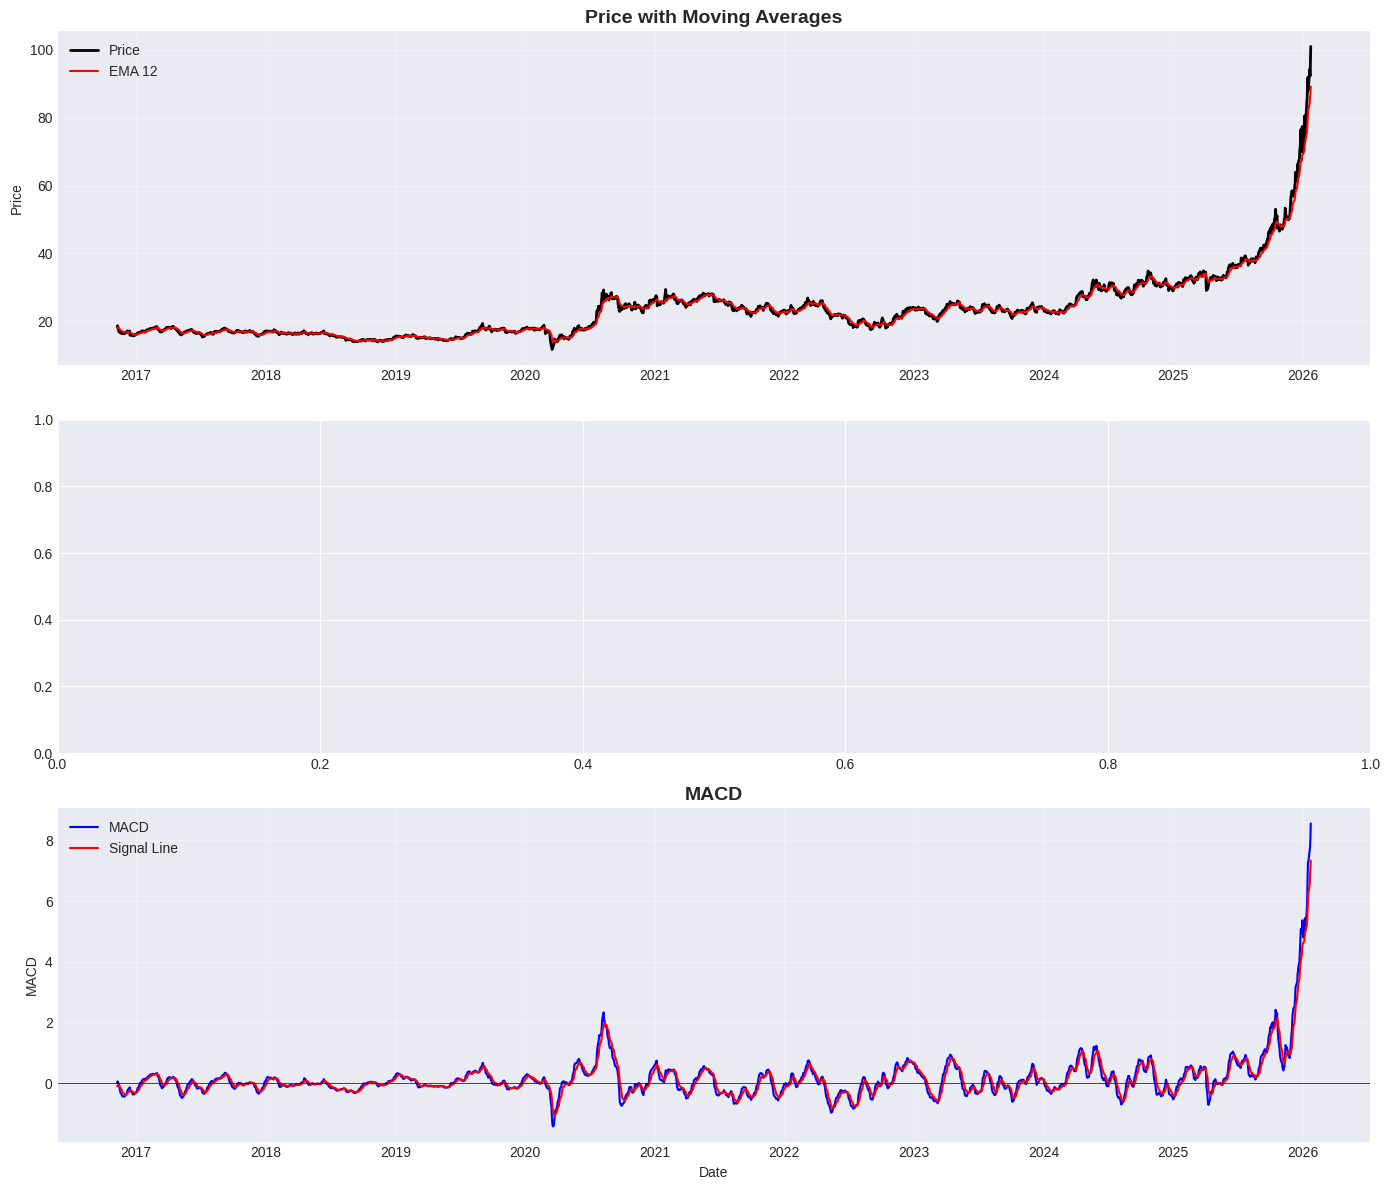

✅ All visualizations generated!

✅ SECTION 9 COMPLETE: Visualizations generated


In [63]:
# ============================================================================
# ALPHAPULSE - SECTION 9: GENERATE VISUALIZATIONS
# ============================================================================

# Generate all plots
alp.generate_visualizations()

print("\n" + "="*60)
print("✅ SECTION 9 COMPLETE: Visualizations generated")
print("="*60)

In [25]:
class Visualizer:
    """Creates all visualizations for AlphaPulse"""

    def __init__(self, config):
        self.config = config
        plt.style.use(config.PLOT_THEME)

    def plot_price_history(self, df, price_col, date_col):
        """Plot price history"""
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        # Price chart
        axes[0].plot(df[date_col], df[price_col], linewidth=2, color='blue')
        axes[0].set_title('Price History', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Price ($)')
        axes[0].grid(True, alpha=0.3)

        # Volume chart (if available)
        if self.config.VOLUME_COLUMN in df.columns:
            axes[1].bar(df[date_col], df[self.config.VOLUME_COLUMN], color='gray', alpha=0.7)
            axes[1].set_title('Trading Volume', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Volume')
            axes[1].set_xlabel('Date')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].set_visible(False)

        plt.tight_layout()
        return fig

    def plot_returns_distribution(self, returns):
        """Plot returns distribution"""
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Histogram
        axes[0].hist(returns, bins=50, alpha=0.7, color='blue', edgecolor='black', density=True)
        axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Return')
        axes[0].axvline(x=returns.mean(), color='green', linestyle='--', linewidth=2,
                       label=f'Mean: {returns.mean():.4f}')
        axes[0].set_title('Returns Distribution', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Daily Return')
        axes[0].set_ylabel('Frequency')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Q-Q plot for normality check
        scipy.stats.probplot(returns, dist="norm", plot=axes[1])
        axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_rolling_volatility(self, rolling_vol, returns):
        """Plot rolling volatility"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

        # Rolling volatility
        rolling_vol.plot(ax=ax1, color='red', linewidth=2)
        ax1.axhline(y=rolling_vol.mean(), color='blue', linestyle='--', alpha=0.7,
                   label=f'Mean: {rolling_vol.mean():.2%}')
        ax1.fill_between(rolling_vol.index, rolling_vol, rolling_vol.mean(),
                        alpha=0.3, where=(rolling_vol > rolling_vol.mean()),
                        color='red', label='Above average')
        ax1.fill_between(rolling_vol.index, rolling_vol, rolling_vol.mean(),
                        alpha=0.3, where=(rolling_vol < rolling_vol.mean()),
                        color='green', label='Below average')
        ax1.set_title(f'{self.config.VOLATILITY_WINDOW}-Day Rolling Volatility (Annualized)',
                     fontsize=14, fontweight='bold')
        ax1.set_ylabel('Volatility')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Returns with volatility bands
        rolling_mean = returns.rolling(self.config.VOLATILITY_WINDOW).mean()
        rolling_std = returns.rolling(self.config.VOLATILITY_WINDOW).std()

        returns.plot(ax=ax2, color='black', alpha=0.5, label='Daily Returns')
        rolling_mean.plot(ax=ax2, color='blue', linewidth=2, label=f'{self.config.VOLATILITY_WINDOW}-day MA')
        ax2.fill_between(rolling_mean.index,
                        rolling_mean - 2*rolling_std,
                        rolling_mean + 2*rolling_std,
                        alpha=0.2, color='gray', label='±2 Std Dev')
        ax2.set_title('Returns with Volatility Bands', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Return')
        ax2.set_xlabel('Date')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_monte_carlo(self, mc_results):
        """Plot Monte Carlo simulation results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Distribution of final values
        ax1 = axes[0, 0]
        ax1.hist(mc_results['final_values'], bins=100, alpha=0.7, color='blue', edgecolor='black')
        ax1.axvline(x=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', linewidth=2,
                   label=f'Initial: ${self.config.INITIAL_INVESTMENT:,.0f}')
        ax1.axvline(x=mc_results['var_95'], color='orange', linestyle='--', linewidth=2,
                   label=f'VaR(95%): ${mc_results["var_95"]:,.0f}')
        ax1.axvline(x=mc_results['mean_final'], color='green', linestyle='--', linewidth=2,
                   label=f'Mean: ${mc_results["mean_final"]:,.0f}')
        ax1.set_title('Distribution of Portfolio Values (1 Year)', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Portfolio Value ($)')
        ax1.set_ylabel('Frequency')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Cumulative probability
        ax2 = axes[0, 1]
        sorted_values = np.sort(mc_results['final_values'])
        p = np.arange(len(sorted_values)) / float(len(sorted_values))
        ax2.plot(sorted_values, p, linewidth=2)
        ax2.axvline(x=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', alpha=0.7)
        ax2.axvline(x=mc_results['var_95'], color='orange', linestyle='--', alpha=0.7)
        ax2.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Portfolio Value ($)')
        ax2.set_ylabel('Cumulative Probability')
        ax2.grid(True, alpha=0.3)

        # 3. Sample of simulation paths
        ax3 = axes[1, 0]
        n_paths = min(100, mc_results['portfolio_paths'].shape[1])
        for i in range(n_paths):
            ax3.plot(mc_results['portfolio_paths'][:, i], alpha=0.1, color='blue')
        ax3.axhline(y=self.config.INITIAL_INVESTMENT, color='red', linestyle='--', linewidth=2)
        ax3.set_title(f'Sample of {n_paths} Simulation Paths', fontsize=12, fontweight='bold')
        ax3.set_xlabel('Trading Days')
        ax3.set_ylabel('Portfolio Value ($)')
        ax3.grid(True, alpha=0.3)

        # 4. Risk metrics summary
        ax4 = axes[1, 1]
        ax4.axis('off')
        metrics_text = f"""
        {'='*40}
        MONTE CARLO RISK SUMMARY
        {'='*40}

        Initial Investment: ${self.config.INITIAL_INVESTMENT:,.0f}

        Value at Risk (95%): ${mc_results['var_95']:,.0f}
        Value at Risk (99%): ${mc_results['var_99']:,.0f}
        Expected Shortfall (95%): ${mc_results['cvar_95']:,.0f}

        Mean Final Value: ${mc_results['mean_final']:,.0f}
        Median Final Value: ${mc_results['median_final']:,.0f}
        Std Deviation: ${mc_results['std_final']:,.0f}

        Probability of Loss: {mc_results['prob_loss']:.1f}%
        Probability of Gain: {mc_results['prob_gain']:.1f}%

        Maximum Loss: ${self.config.INITIAL_INVESTMENT - mc_results['var_99']:,.0f}
        Maximum Gain: ${mc_results['final_values'].max() - self.config.INITIAL_INVESTMENT:,.0f}
        """
        ax4.text(0.1, 0.9, metrics_text, transform=ax4.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.suptitle('Monte Carlo Simulation Analysis (10,000 Runs)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        return fig

    def plot_drawdown(self, drawdown, max_dd, max_dd_date):
        """Plot drawdown chart"""
        fig, ax = plt.subplots(figsize=(14, 6))

        drawdown.plot(ax=ax, color='red', linewidth=1)
        ax.fill_between(drawdown.index, drawdown, 0, where=(drawdown < 0),
                       color='red', alpha=0.3)
        ax.axhline(y=max_dd, color='black', linestyle='--', alpha=0.7,
                  label=f'Max Drawdown: {max_dd:.2%} ({max_dd_date.strftime("%Y-%m-%d")})')
        ax.set_title('Portfolio Drawdown Analysis', fontsize=14, fontweight='bold')
        ax.set_ylabel('Drawdown')
        ax.set_xlabel('Date')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def plot_technical_indicators(self, df, tech_df):
        """Plot technical indicators if available"""
        if tech_df is None or tech_df.empty:
            return None

        fig, axes = plt.subplots(3, 1, figsize=(14, 12))

        # Price and moving averages
        axes[0].plot(df[self.config.DATE_COLUMN], df[self.config.PRICE_COLUMN],
                    linewidth=2, color='black', label='Price')

        if 'SMA_20' in tech_df.columns:
            axes[0].plot(tech_df.index, tech_df['SMA_20'],
                        linewidth=1.5, color='blue', label='SMA 20')
        if 'EMA_12' in tech_df.columns:
            axes[0].plot(tech_df.index, tech_df['EMA_12'],
                        linewidth=1.5, color='red', label='EMA 12')

        axes[0].set_title('Price with Moving Averages', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('Price')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Bollinger Bands
        if all(col in tech_df.columns for col in ['BB_MidleBB', 'Upper BB', 'Lower RSI']):
            axes[1].plot(tech_df.index, tech_df['BB_MidleBB'],
                        linewidth=1.5, color='blue', label='Middle BB')
            axes[1].plot(tech_df.index, tech_df['Upper BB'],
                        linewidth=1, color='gray', linestyle='--', label='Upper BB')
            axes[1].plot(tech_df.index, tech_df['Lower RSI'],
                        linewidth=1, color='gray', linestyle='--', label='Lower BB')
            axes[1].fill_between(tech_df.index, tech_df['Upper BB'], tech_df['Lower RSI'],
                                alpha=0.1, color='gray')
            axes[1].set_title('Bollinger Bands', fontsize=14, fontweight='bold')
            axes[1].set_ylabel('Price')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        # MACD
        if all(col in tech_df.columns for col in ['MACD', 'Signal_Line']):
            axes[2].plot(tech_df.index, tech_df['MACD'],
                        linewidth=1.5, color='blue', label='MACD')
            axes[2].plot(tech_df.index, tech_df['Signal_Line'],
                        linewidth=1.5, color='red', label='Signal Line')

            if 'MACD_Hi_Sigh_Low' in tech_df.columns:
                axes[2].bar(tech_df.index, tech_df['MACD_Hi_Sigh_Low'],
                           alpha=0.3, color='gray', label='Histogram')

            axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            axes[2].set_title('MACD', fontsize=14, fontweight='bold')
            axes[2].set_ylabel('MACD')
            axes[2].set_xlabel('Date')
            axes[2].legend()
            axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

    def create_interactive_price_chart(self, df, price_col, date_col):
        """Create interactive plotly price chart"""
        fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                           vertical_spacing=0.03,
                           row_heights=[0.7, 0.3])

        # Price line
        fig.add_trace(
            go.Scatter(x=df[date_col], y=df[price_col],
                      mode='lines',
                      name='Price',
                      line=dict(color='blue', width=2)),
            row=1, col=1
        )

        # Volume bars
        if self.config.VOLUME_COLUMN in df.columns:
            fig.add_trace(
                go.Bar(x=df[date_col], y=df[self.config.VOLUME_COLUMN],
                       name='Volume',
                       marker_color='gray',
                       opacity=0.5),
                row=2, col=1
            )

        fig.update_layout(
            title='Interactive Price Chart',
            xaxis_title='Date',
            yaxis_title='Price',
            hovermode='x unified',
            height=600,
            showlegend=True
        )

        fig.update_xaxes(title_text="Date", row=2, col=1)
        fig.update_yaxes(title_text="Price", row=1, col=1)
        fig.update_yaxes(title_text="Volume", row=2, col=1)

        return fig

print(" Visualizer class loaded")


 Visualizer class loaded


In [66]:


# Export to CSV
alp.export_results()

# Display output files
print("\n Generated Files:")
!ls -la /content/alphapulse_output/

# Download the zip file
from google.colab import files
files.download('/content/alphapulse_results.zip')

print("\n" + "="*60)
print(" SECTION 10 COMPLETE: Results exported and downloaded")
print("="*60)


💾 Exporting results to CSV...
  ✅ cleaned_data.csv
  ✅ returns.csv
  ✅ rolling_volatility.csv
  ✅ monte_carlo_results.csv
  ✅ drawdown.csv
  ✅ portfolio_summary.csv
  ✅ technical_indicators.csv

📁 All files saved to: /content/alphapulse_output/
updating: content/alphapulse_output/ (stored 0%)
updating: content/alphapulse_output/monte_carlo_results.csv (deflated 51%)
updating: content/alphapulse_output/rolling_volatility.csv (deflated 61%)
updating: content/alphapulse_output/portfolio_summary.csv (deflated 32%)
updating: content/alphapulse_output/drawdown.csv (deflated 63%)
updating: content/alphapulse_output/cleaned_data.csv (deflated 66%)
updating: content/alphapulse_output/technical_indicators.csv (deflated 58%)
updating: content/alphapulse_output/returns.csv (deflated 61%)

📦 Created: alphapulse_results.zip

 Generated Files:
total 1516
drwxr-xr-x 2 root root   4096 Mar  6 19:43 .
drwxr-xr-x 1 root root   4096 Mar  6 20:13 ..
-rw-r--r-- 1 root root 935779 Mar  6 20:13 cleaned_data.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 SECTION 10 COMPLETE: Results exported and downloaded


In [64]:


# Create a quick summary dashboard
print("\n" + "="*60)
print(" ALPHAPULSE - EXECUTIVE SUMMARY DASHBOARD")
print("="*60)

# Basic Statistics
print("\n BASIC STATISTICS:")
print("-"*40)
stats = alp.preprocessor.get_summary_stats()
for idx, row in stats.iterrows():
    print(f"  {idx}: {row['Value']:.4f}")

# Risk Metrics Summary
print("\n RISK METRICS:")
print("-"*40)
print(f"  Historical VaR (95%):      {results['var_historical']:>8.2%}  (${results['var_historical_dollar']:>12,.0f})")
print(f"  Parametric VaR (95%):      {results['var_parametric']:>8.2%}  (${results['var_parametric_dollar']:>12,.0f})")
print(f"  Conditional VaR (95%):     {results['cvar']:>8.2%}  (${results['cvar_dollar']:>12,.0f})")
print(f"  Current Volatility:        {results['rolling_volatility'].iloc[-1]:>8.2%}")
print(f"  Average Volatility:        {results['rolling_volatility'].mean():>8.2%}")
print(f"  Sharpe Ratio:              {results['sharpe_ratio']:>8.2f}")
print(f"  Calmar Ratio:              {results['calmar_ratio']:>8.2f}")
print(f"  Max Drawdown:              {results['max_drawdown']:>8.2%}")
print(f"  Max Drawdown Date:         {results['max_drawdown_date'].strftime('%Y-%m-%d')}")

# Monte Carlo Summary
print("\n MONTE CARLO (10,000 simulations):")
print("-"*40)
print(f"  Initial Investment:        ${Config.INITIAL_INVESTMENT:>12,.0f}")
print(f"  VaR (95%):                 ${results['mc_results']['var_95']:>12,.0f}")
print(f"  VaR (99%):                 ${results['mc_results']['var_99']:>12,.0f}")
print(f"  Expected Shortfall (95%):  ${results['mc_results']['cvar_95']:>12,.0f}")
print(f"  Mean Final Value:          ${results['mc_results']['mean_final']:>12,.0f}")
print(f"  Median Final Value:          ${results['mc_results']['median_final']:>12,.0f}")
print(f"  Probability of Loss:       {results['mc_results']['prob_loss']:>11.1f}%")
print(f"  Probability of Gain:       {results['mc_results']['prob_gain']:>11.1f}%")

# Data Quality
print("\n DATA QUALITY:")
print("-"*40)
print(f"  Date Range: {alp.cleaned_data[Config.DATE_COLUMN].min().strftime('%Y-%m-%d')} to {alp.cleaned_data[Config.DATE_COLUMN].max().strftime('%Y-%m-%d')}")
print(f"  Total Trading Days: {len(alp.cleaned_data)}")
print(f"  Missing Values: {alp.cleaned_data.isnull().sum().sum()}")

print("\n" + "="*60)
print(" END OF ANALYSIS")
print("="*60)


 ALPHAPULSE - EXECUTIVE SUMMARY DASHBOARD

 BASIC STATISTICS:
----------------------------------------
  Mean Return: 0.2334
  Volatility: 0.3081
  Skewness: -0.1875
  Kurtosis: 5.0873
  Min Return: -0.1165
  Max Return: 0.1076

 RISK METRICS:
----------------------------------------
  Historical VaR (95%):        -2.78%  ($     -27,812)
  Parametric VaR (95%):        -3.10%  ($     -30,998)
  Conditional VaR (95%):       -4.55%  ($     -45,541)
  Current Volatility:          78.94%
  Average Volatility:          27.67%
  Sharpe Ratio:                  0.69
  Calmar Ratio:                  0.58
  Max Drawdown:               -40.30%
  Max Drawdown Date:         2022-09-01

 MONTE CARLO (10,000 simulations):
----------------------------------------
  Initial Investment:        $   1,000,000
  VaR (95%):                 $     760,565
  VaR (99%):                 $     622,135
  Expected Shortfall (95%):  $     677,057
  Mean Final Value:          $   1,334,299
  Median Final Value:      